In [36]:
print("Airport Passenger Experience Analysis")

Airport Passenger Experience Analysis


# Airport Passenger Experience with Self-Service Technologies

## Data Analysis Project

This project analyzes passenger experiences with airport self-service technologies (SSTs), including self-check-in kiosks, self-bag drop systems, mobile check-in applications, biometric boarding, and automated passport control/e-gates.

The analysis is based on an anonymized survey dataset of **80 airport passengers** who reported experience with airport self-service technologies.

### Objectives

The project explores:

- Passenger use of different airport self-service technologies
- Ease of use, perceived time savings, reliability, and assistance requirements
- Overall passenger satisfaction
- Future preferences for self-service and human-assisted services
- Relationships between passenger experience factors and satisfaction
- Differences in satisfaction across passenger groups
- Passenger suggestions for improving airport self-service technologies

### Methods

The analysis was conducted in Python using:

- pandas
- matplotlib
- scipy
- Descriptive statistics
- Frequency and percentage analysis
- Spearman rank-order correlation
- Kruskal-Wallis tests
- Basic thematic analysis of open-ended responses

> **Privacy note:** The respondent-level dataset is not included in this public repository. The notebook demonstrates the analysis workflow using the research dataset privately.

## 1. Data Loading

The analysis uses an anonymized dataset containing responses from 80 participants.

For research-ethics and privacy reasons, the respondent-level dataset is not included in this public repository. To reproduce the analysis with an authorized copy of the dataset, place `combined_80_responses.xlsx` in the working directory before running the notebook.

In [37]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("combined_80_responses.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. The respondent-level dataset is private and "
        "is not included in this public repository."
    )

df = pd.read_excel(DATA_PATH)

print("Number of responses:", len(df))
print("Number of variables:", len(df.columns))

df.head()

Number of responses: 80
Number of variables: 10


,Age Group,Travel Frequency,SSTs Used,Ease of Use (1-5),Time Saved,Reliability,Assistance Needed,Overall Satisfaction,Future Preference,Suggestions
0,Over 50,Frequently,"Automated passport control / e-gates, Self-che...",4,A lot,Not reliable,"No, everything was clear",Very dissatisfied,Use a mix of both,Improve screen instructions
1,18-25,Frequently,Mobile check-in / airline app,1,A moderate amount,Very reliable,"No, everything was clear",Neutral,Use a mix of both,No suggestions
2,26-35,Occasionally,"Self-check-in kiosk, Mobile check-in / airline...",5,It made things slower,Very reliable,"Yes, multiple times",Very satisfied,Use a mix of both,Improve screen instructions
3,26â€“35,Occasionally,"Mobile check-in / airline app, Self-bag drop, ...",1,None at all,Not reliable,"Yes, multiple times",Dissatisfied,Not sure,Improve screen instructions
4,26â€“35,Occasionally,"Biometric boarding (face/fingerprint), Self-ba...",4,A little,Not reliable,"No, everything was clear",Dissatisfied,Return to human-assisted service,NaN


In [38]:
import pandas as pd

df = pd.read_excel("/combined_80_responses.xlsx")

print("Number of responses:", len(df))
print("Number of variables:", len(df.columns))

df.head()

Number of responses: 80
Number of variables: 10


,Age Group,Travel Frequency,SSTs Used,Ease of Use (1-5),Time Saved,Reliability,Assistance Needed,Overall Satisfaction,Future Preference,Suggestions
0,Over 50,Frequently,"Automated passport control / e-gates, Self-che...",4,A lot,Not reliable,"No, everything was clear",Very dissatisfied,Use a mix of both,Improve screen instructions
1,18-25,Frequently,Mobile check-in / airline app,1,A moderate amount,Very reliable,"No, everything was clear",Neutral,Use a mix of both,No suggestions
2,26-35,Occasionally,"Self-check-in kiosk, Mobile check-in / airline...",5,It made things slower,Very reliable,"Yes, multiple times",Very satisfied,Use a mix of both,Improve screen instructions
3,26â€“35,Occasionally,"Mobile check-in / airline app, Self-bag drop, ...",1,None at all,Not reliable,"Yes, multiple times",Dissatisfied,Not sure,Improve screen instructions
4,26â€“35,Occasionally,"Biometric boarding (face/fingerprint), Self-ba...",4,A little,Not reliable,"No, everything was clear",Dissatisfied,Return to human-assisted service,NaN


## 2. Data Inspection and Cleaning

Before analysis, the dataset was inspected for its structure, missing values, and consistency of categorical responses.

The cleaning process included:

- Checking the number of observations and variables
- Identifying missing values
- Inspecting categorical response values
- Correcting text-encoding inconsistencies in age-group labels
- Preparing ordinal variables for statistical analysis

The final analytical sample consisted of **80 respondents**.

In [39]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique Age Groups:")
print(df["Age Group"].unique())

Dataset shape: (80, 10)

Missing values:
Age Group               0
Travel Frequency        0
SSTs Used               0
Ease of Use (1-5)       0
Time Saved              0
Reliability             0
Assistance Needed       0
Overall Satisfaction    0
Future Preference       0
Suggestions             9
dtype: int64

Unique Age Groups:
['Over 50' '18-25' '26-35' '26â€“35' '36â€“50' '18â€“25']


In [40]:
df["Age Group"] = df["Age Group"].replace({
    "18â€“25": "18-25",
    "26â€“35": "26-35",
    "36â€“50": "36-50"
})

print(df["Age Group"].value_counts())

Age Group
Over 50    23
18-25      20
26-35      20
36-50      17
Name: count, dtype: int64


In [41]:
for column in df.columns:
    if df[column].dtype == "object":
        print("\n---", column, "---")
        print(df[column].value_counts())


--- Age Group ---
Age Group
Over 50    23
18-25      20
26-35      20
36-50      17
Name: count, dtype: int64

--- Travel Frequency ---
Travel Frequency
Occasionally       22
Very frequently    22
Frequently         19
Rarely             17
Name: count, dtype: int64

--- SSTs Used ---
SSTs Used
Self-bag drop                                                                                                                      7
Biometric boarding (face/fingerprint)                                                                                              5
Self-check-in kiosk                                                                                                                4
Mobile check-in / airline app                                                                                                      3
Self-check-in kiosk, Automated passport control / e-gates, Self-bag drop                                                           2
Self-bag drop, Biometric boarding (fac

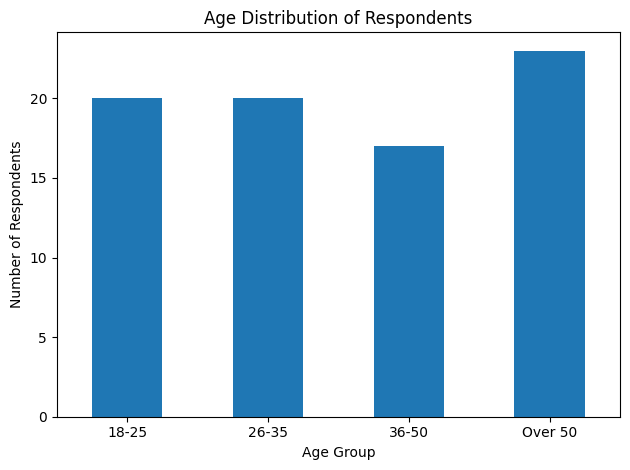

In [43]:
import matplotlib.pyplot as plt

age_order = ["18-25", "26-35", "36-50", "Over 50"]
age_counts = df["Age Group"].value_counts().reindex(age_order)

age_counts.plot(kind="bar")

plt.title("Age Distribution of Respondents")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Travel Frequency
Occasionally       22
Very frequently    22
Frequently         19
Rarely             17
Name: count, dtype: int64


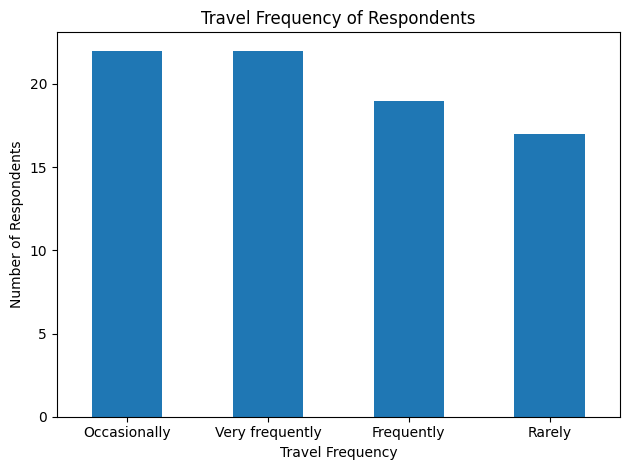

In [44]:
travel_counts = df["Travel Frequency"].value_counts()

print(travel_counts)

travel_counts.plot(kind="bar")

plt.title("Travel Frequency of Respondents")
plt.xlabel("Travel Frequency")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Overall Satisfaction
Very dissatisfied    13
Dissatisfied         19
Neutral              16
Satisfied            13
Very satisfied       19
Name: count, dtype: int64


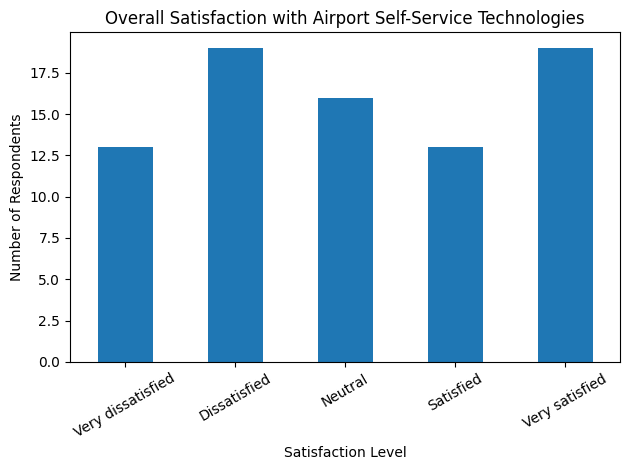

In [45]:
satisfaction_order = [
    "Very dissatisfied",
    "Dissatisfied",
    "Neutral",
    "Satisfied",
    "Very satisfied"
]

satisfaction_counts = (
    df["Overall Satisfaction"]
    .value_counts()
    .reindex(satisfaction_order)
)

print(satisfaction_counts)

satisfaction_counts.plot(kind="bar")

plt.title("Overall Satisfaction with Airport Self-Service Technologies")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

count    80.000000
mean      3.050000
std       1.448701
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: Ease of Use (1-5), dtype: float64

Ease of Use Ratings:
Ease of Use (1-5)
1    18
2    11
3    16
4    19
5    16
Name: count, dtype: int64


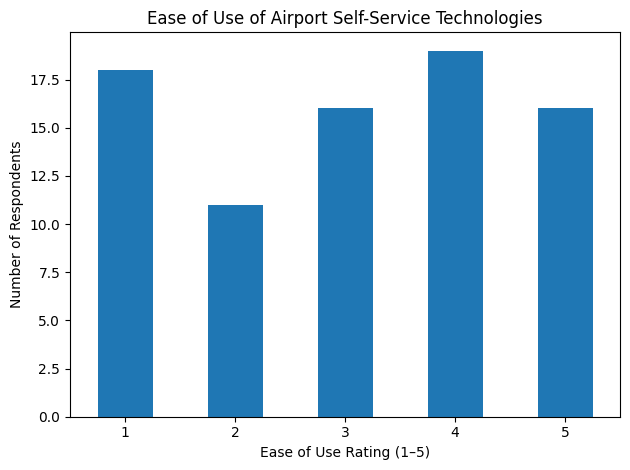

In [46]:
print(df["Ease of Use (1-5)"].describe())

ease_counts = df["Ease of Use (1-5)"].value_counts().sort_index()
print("\nEase of Use Ratings:")
print(ease_counts)

ease_counts.plot(kind="bar")

plt.title("Ease of Use of Airport Self-Service Technologies")
plt.xlabel("Ease of Use Rating (1–5)")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Time Saved:
Time Saved
A moderate amount        22
None at all              20
A little                 16
A lot                    12
It made things slower    10
Name: count, dtype: int64


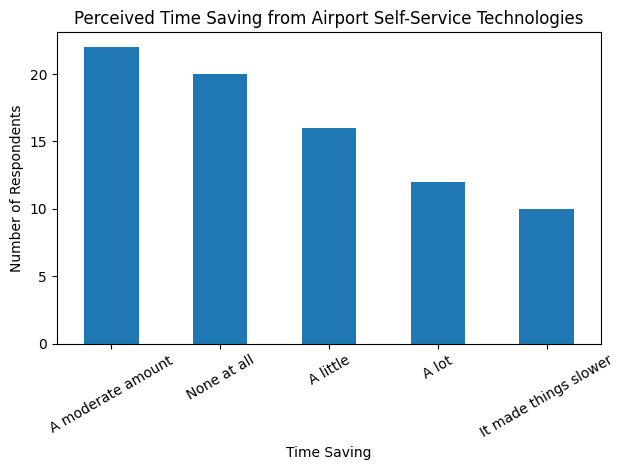

In [47]:
time_counts = df["Time Saved"].value_counts()

print("Time Saved:")
print(time_counts)

time_counts.plot(kind="bar")

plt.title("Perceived Time Saving from Airport Self-Service Technologies")
plt.xlabel("Time Saving")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Reliability:
Reliability
Not reliable         28
Somewhat reliable    27
Very reliable        25
Name: count, dtype: int64


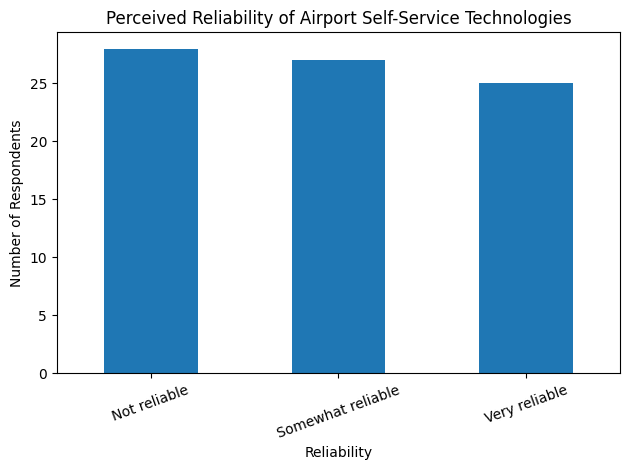

In [48]:
reliability_counts = df["Reliability"].value_counts()

print("Reliability:")
print(reliability_counts)

reliability_counts.plot(kind="bar")

plt.title("Perceived Reliability of Airport Self-Service Technologies")
plt.xlabel("Reliability")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Assistance Needed:
Assistance Needed
I couldnt use it without help    28
Yes, but only once               21
No, everything was clear         20
Yes, multiple times              11
Name: count, dtype: int64


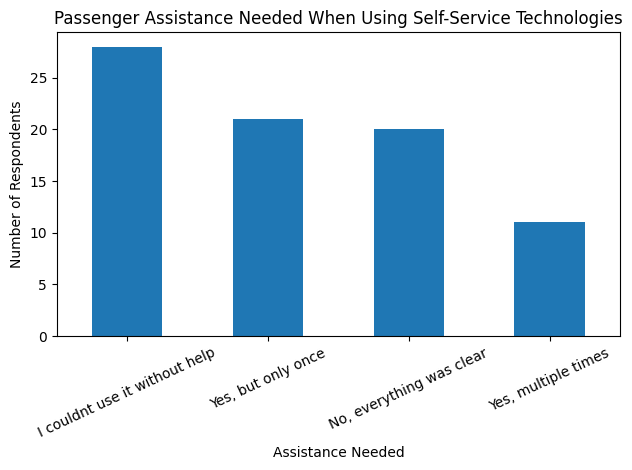

In [49]:
assistance_counts = df["Assistance Needed"].value_counts()

print("Assistance Needed:")
print(assistance_counts)

assistance_counts.plot(kind="bar")

plt.title("Passenger Assistance Needed When Using Self-Service Technologies")
plt.xlabel("Assistance Needed")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Future Preference:
Future Preference
Not sure                              25
Use self-service technologies more    22
Use a mix of both                     21
Return to human-assisted service      12
Name: count, dtype: int64


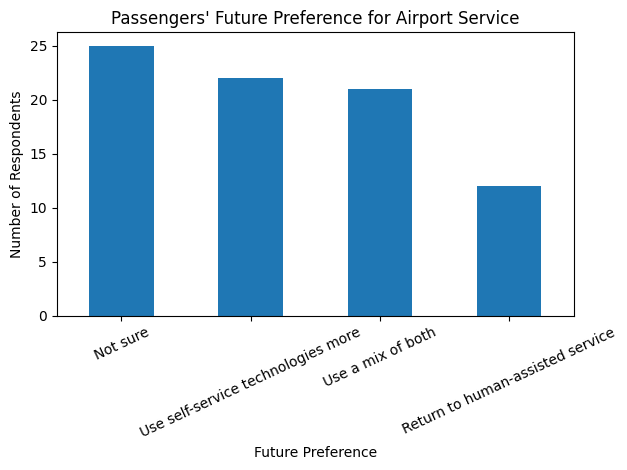

In [50]:
future_counts = df["Future Preference"].value_counts()

print("Future Preference:")
print(future_counts)

future_counts.plot(kind="bar")

plt.title("Passengers' Future Preference for Airport Service")
plt.xlabel("Future Preference")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 4. Statistical Analysis

Ordinal survey responses were converted into numerical scores to support non-parametric statistical analysis.

The analysis includes:

- Descriptive statistics for ordinal variables
- Spearman rank-order correlations with overall satisfaction
- Kruskal-Wallis tests for differences in satisfaction across passenger groups
- Comparison of satisfaction across future service preferences

Non-parametric methods were used because the primary survey measures were ordinal.

In [51]:
satisfaction_map = {
    "Very dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very satisfied": 5
}

df["Satisfaction Score"] = df["Overall Satisfaction"].map(satisfaction_map)

print(
    df[["Ease of Use (1-5)", "Overall Satisfaction", "Satisfaction Score"]]
    .head(10)
)

   Ease of Use (1-5) Overall Satisfaction  Satisfaction Score
0                  4    Very dissatisfied                   1
1                  1              Neutral                   3
2                  5       Very satisfied                   5
3                  1         Dissatisfied                   2
4                  4         Dissatisfied                   2
5                  4       Very satisfied                   5
6                  2    Very dissatisfied                   1
7                  5         Dissatisfied                   2
8                  2         Dissatisfied                   2
9                  5    Very dissatisfied                   1


In [52]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    df["Ease of Use (1-5)"],
    df["Satisfaction Score"]
)

print("Spearman correlation:", round(rho, 3))
print("p-value:", round(p_value, 4))

Spearman correlation: 0.081
p-value: 0.4732


In [53]:
time_map = {
    "It made things slower": 1,
    "None at all": 2,
    "A little": 3,
    "A moderate amount": 4,
    "A lot": 5
}

df["Time Saved Score"] = df["Time Saved"].map(time_map)

print(
    df[["Time Saved", "Time Saved Score", "Overall Satisfaction"]]
    .head(10)
)

              Time Saved  Time Saved Score Overall Satisfaction
0                  A lot                 5    Very dissatisfied
1      A moderate amount                 4              Neutral
2  It made things slower                 1       Very satisfied
3            None at all                 2         Dissatisfied
4               A little                 3         Dissatisfied
5            None at all                 2       Very satisfied
6            None at all                 2    Very dissatisfied
7               A little                 3         Dissatisfied
8               A little                 3         Dissatisfied
9      A moderate amount                 4    Very dissatisfied


In [54]:
rho_time, p_time = spearmanr(
    df["Time Saved Score"],
    df["Satisfaction Score"]
)

print("Spearman correlation:", round(rho_time, 3))
print("p-value:", round(p_time, 4))

Spearman correlation: -0.101
p-value: 0.3738


In [55]:
reliability_map = {
    "Not reliable": 1,
    "Somewhat reliable": 2,
    "Very reliable": 3
}

df["Reliability Score"] = df["Reliability"].map(reliability_map)

print(
    df[["Reliability", "Reliability Score", "Overall Satisfaction"]]
    .head(10)
)

         Reliability  Reliability Score Overall Satisfaction
0       Not reliable                  1    Very dissatisfied
1      Very reliable                  3              Neutral
2      Very reliable                  3       Very satisfied
3       Not reliable                  1         Dissatisfied
4       Not reliable                  1         Dissatisfied
5      Very reliable                  3       Very satisfied
6  Somewhat reliable                  2    Very dissatisfied
7  Somewhat reliable                  2         Dissatisfied
8  Somewhat reliable                  2         Dissatisfied
9  Somewhat reliable                  2    Very dissatisfied


In [56]:
rho_rel, p_rel = spearmanr(
    df["Reliability Score"],
    df["Satisfaction Score"]
)

print("Spearman correlation:", round(rho_rel, 3))
print("p-value:", round(p_rel, 4))

Spearman correlation: -0.063
p-value: 0.5798


In [57]:
# ==========================================
# REMAINING STATISTICAL ANALYSIS
# ==========================================

from scipy.stats import spearmanr

# 1. Encode Assistance Needed
assistance_map = {
    "I couldnt use it without help": 1,
    "Yes, multiple times": 2,
    "Yes, but only once": 3,
    "No, everything was clear": 4
}

df["Assistance Score"] = df["Assistance Needed"].map(assistance_map)


# 2. Encode Travel Frequency
travel_map = {
    "Rarely": 1,
    "Occasionally": 2,
    "Frequently": 3,
    "Very frequently": 4
}

df["Travel Frequency Score"] = df["Travel Frequency"].map(travel_map)


# 3. Encode Age Group
age_map = {
    "18-25": 1,
    "26-35": 2,
    "36-50": 3,
    "Over 50": 4
}

df["Age Group Score"] = df["Age Group"].map(age_map)


# 4. Calculate correlations with satisfaction
variables = {
    "Ease of Use": "Ease of Use (1-5)",
    "Time Saved": "Time Saved Score",
    "Reliability": "Reliability Score",
    "Assistance Needed": "Assistance Score",
    "Travel Frequency": "Travel Frequency Score",
    "Age Group": "Age Group Score"
}

results = []

for name, column in variables.items():

    temp = df[[column, "Satisfaction Score"]].dropna()

    rho, p = spearmanr(
        temp[column],
        temp["Satisfaction Score"]
    )

    results.append([
        name,
        len(temp),
        round(rho, 3),
        round(p, 4),
        "Significant" if p < 0.05 else "Not significant"
    ])


# 5. Create final results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "N",
        "Spearman rho",
        "p-value",
        "Result"
    ]
)

print("CORRELATION RESULTS WITH OVERALL SATISFACTION")
print(results_df.to_string(index=False))


# 6. Check whether any values failed to map
print("\nMISSING VALUES AFTER CODING")

print("Assistance Score:",
      df["Assistance Score"].isna().sum())

print("Travel Frequency Score:",
      df["Travel Frequency Score"].isna().sum())

print("Age Group Score:",
      df["Age Group Score"].isna().sum())

print("Time Saved Score:",
      df["Time Saved Score"].isna().sum())

print("Reliability Score:",
      df["Reliability Score"].isna().sum())

print("Satisfaction Score:",
      df["Satisfaction Score"].isna().sum())

CORRELATION RESULTS WITH OVERALL SATISFACTION
         Variable  N  Spearman rho  p-value          Result
      Ease of Use 80         0.081   0.4732 Not significant
       Time Saved 80        -0.101   0.3738 Not significant
      Reliability 80        -0.063   0.5798 Not significant
Assistance Needed 80        -0.055   0.6279 Not significant
 Travel Frequency 80        -0.070   0.5378 Not significant
        Age Group 80        -0.105   0.3530 Not significant

MISSING VALUES AFTER CODING
Assistance Score: 0
Travel Frequency Score: 0
Age Group Score: 0
Time Saved Score: 0
Reliability Score: 0
Satisfaction Score: 0


In [58]:
from scipy.stats import kruskal
import pandas as pd

group_variables = [
    "Age Group",
    "Travel Frequency",
    "Reliability",
    "Assistance Needed",
    "Time Saved"
]

group_results = []

for variable in group_variables:

    # Create one satisfaction-score group for each category
    groups = [
        group["Satisfaction Score"].dropna().values
        for _, group in df.groupby(variable)
    ]

    # Kruskal-Wallis test
    H, p = kruskal(*groups)

    group_results.append([
        variable,
        round(H, 3),
        round(p, 4),
        "Significant" if p < 0.05 else "Not significant"
    ])

group_results_df = pd.DataFrame(
    group_results,
    columns=[
        "Grouping Variable",
        "Kruskal-Wallis H",
        "p-value",
        "Result"
    ]
)

print("GROUP DIFFERENCES IN OVERALL SATISFACTION")
print(group_results_df.to_string(index=False))

GROUP DIFFERENCES IN OVERALL SATISFACTION
Grouping Variable  Kruskal-Wallis H  p-value          Result
        Age Group             5.539   0.1363 Not significant
 Travel Frequency             1.264   0.7378 Not significant
      Reliability             0.402   0.8178 Not significant
Assistance Needed             3.585   0.3099 Not significant
       Time Saved             3.268   0.5140 Not significant


In [59]:
# ==========================================
# DESCRIPTIVE STATISTICS SUMMARY
# ==========================================

summary_variables = {
    "Ease of Use": "Ease of Use (1-5)",
    "Time Saved": "Time Saved Score",
    "Reliability": "Reliability Score",
    "Assistance": "Assistance Score",
    "Travel Frequency": "Travel Frequency Score",
    "Age Group": "Age Group Score",
    "Overall Satisfaction": "Satisfaction Score"
}

summary_results = []

for name, column in summary_variables.items():

    data = df[column].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    summary_results.append([
        name,
        len(data),
        round(data.median(), 2),
        round(q1, 2),
        round(q3, 2),
        round(q3 - q1, 2),
        data.min(),
        data.max()
    ])

summary_df = pd.DataFrame(
    summary_results,
    columns=[
        "Variable",
        "N",
        "Median",
        "Q1",
        "Q3",
        "IQR",
        "Minimum",
        "Maximum"
    ]
)

print("DESCRIPTIVE STATISTICS")
print(summary_df.to_string(index=False))

DESCRIPTIVE STATISTICS
            Variable  N  Median   Q1   Q3  IQR  Minimum  Maximum
         Ease of Use 80     3.0 2.00 4.00 2.00        1        5
          Time Saved 80     3.0 2.00 4.00 2.00        1        5
         Reliability 80     2.0 1.00 3.00 2.00        1        3
          Assistance 80     3.0 1.00 3.25 2.25        1        4
    Travel Frequency 80     3.0 2.00 4.00 2.00        1        4
           Age Group 80     2.5 1.75 4.00 2.25        1        4
Overall Satisfaction 80     3.0 2.00 4.00 2.00        1        5


In [60]:
# ==========================================
# FREQUENCY AND PERCENTAGE TABLES
# ==========================================

categorical_variables = [
    "Age Group",
    "Travel Frequency",
    "Time Saved",
    "Reliability",
    "Assistance Needed",
    "Overall Satisfaction",
    "Future Preference"
]

for variable in categorical_variables:

    counts = df[variable].value_counts(dropna=False)
    percentages = df[variable].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    table = pd.DataFrame({
        "Frequency": counts,
        "Percentage": percentages.round(1)
    })

    print("\n" + "=" * 60)
    print(variable.upper())
    print("=" * 60)
    print(table)


AGE GROUP
           Frequency  Percentage
Age Group                       
Over 50           23        28.7
18-25             20        25.0
26-35             20        25.0
36-50             17        21.2

TRAVEL FREQUENCY
                  Frequency  Percentage
Travel Frequency                       
Occasionally             22        27.5
Very frequently          22        27.5
Frequently               19        23.8
Rarely                   17        21.2

TIME SAVED
                       Frequency  Percentage
Time Saved                                  
A moderate amount             22        27.5
None at all                   20        25.0
A little                      16        20.0
A lot                         12        15.0
It made things slower         10        12.5

RELIABILITY
                   Frequency  Percentage
Reliability                             
Not reliable              28        35.0
Somewhat reliable         27        33.8
Very reliable             25 

In [61]:
# ==========================================
# SELF-SERVICE TECHNOLOGIES USED
# Multiple-response analysis
# ==========================================

sst_counts = (
    df["SSTs Used"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

sst_percent = (sst_counts / len(df) * 100).round(1)

sst_table = pd.DataFrame({
    "Frequency": sst_counts,
    "Percentage of Respondents": sst_percent
})

print("SELF-SERVICE TECHNOLOGIES USED")
print(sst_table)

SELF-SERVICE TECHNOLOGIES USED
                                       Frequency  Percentage of Respondents
SSTs Used                                                                  
Self-bag drop                                 46                       57.5
Mobile check-in / airline app                 42                       52.5
Automated passport control / e-gates          39                       48.8
Self-check-in kiosk                           37                       46.2
Biometric boarding (face/fingerprint)         35                       43.8


## 5. Open-Ended Response Analysis

Passenger suggestions were analyzed to identify recurring themes related to the improvement of airport self-service technologies.

A total of **71 respondents provided a written response**, while 9 responses were missing.

The main themes identified were:

- Improving on-screen instructions
- Providing staff assistance near self-service systems
- Adding more language options
- Improving the speed of biometric gates
- No additional suggestions

Among the 52 responses containing a substantive improvement suggestion, **improving screen instructions was the most frequently reported theme**.

In [62]:
# ==========================================
# DISPLAY ALL WRITTEN SUGGESTIONS
# ==========================================

suggestions = df["Suggestions"].dropna()

print("Number of written responses:", len(suggestions))
print("\nWRITTEN SUGGESTIONS\n")

for i, response in enumerate(suggestions, 1):
    print(f"{i}. {response}")

Number of written responses: 71

WRITTEN SUGGESTIONS

1. Improve screen instructions
2. No suggestions
3. Improve screen instructions
4. Improve screen instructions
5. Make biometric gates faster
6. No suggestions
7. Improve screen instructions
8. No suggestions
9. No suggestions
10. No suggestions
11. No suggestions
12. No suggestions
13. Improve screen instructions
14. No suggestions
15. Ensure staff nearby to help
16. Make biometric gates faster
17. Improve screen instructions
18. No suggestions
19. Make biometric gates faster
20. No suggestions
21. Improve screen instructions
22. Add more language options
23. Improve screen instructions
24. Make biometric gates faster
25. Add more language options
26. Ensure staff nearby to help
27. Ensure staff nearby to help
28. Improve screen instructions
29. Make biometric gates faster
30. No suggestions
31. Ensure staff nearby to help
32. Improve screen instructions
33. Add more language options
34. Make biometric gates faster
35. Improve scre

In [63]:
# ==========================================
# THEMATIC ANALYSIS OF WRITTEN SUGGESTIONS
# ==========================================

theme_counts = suggestions.value_counts()

theme_percent_71 = (theme_counts / len(suggestions) * 100).round(1)
theme_percent_80 = (theme_counts / len(df) * 100).round(1)

theme_table = pd.DataFrame({
    "Frequency": theme_counts,
    "% of Written Responses": theme_percent_71,
    "% of All Respondents": theme_percent_80
})

print("THEMATIC ANALYSIS OF PASSENGER SUGGESTIONS")
print(theme_table)

print("\nTotal written responses:", len(suggestions))
print("Total sample:", len(df))

THEMATIC ANALYSIS OF PASSENGER SUGGESTIONS
                             Frequency  % of Written Responses  \
Suggestions                                                      
Improve screen instructions         19                    26.8   
No suggestions                      19                    26.8   
Ensure staff nearby to help         12                    16.9   
Add more language options           11                    15.5   
Make biometric gates faster         10                    14.1   

                             % of All Respondents  
Suggestions                                        
Improve screen instructions                  23.8  
No suggestions                               23.8  
Ensure staff nearby to help                  15.0  
Add more language options                    13.8  
Make biometric gates faster                  12.5  

Total written responses: 71
Total sample: 80


In [64]:
from scipy.stats import kruskal

# ==========================================
# FUTURE PREFERENCE vs OVERALL SATISFACTION
# ==========================================

preference_groups = []

for preference in df["Future Preference"].dropna().unique():
    scores = df.loc[
        df["Future Preference"] == preference,
        "Satisfaction Score"
    ].dropna()

    preference_groups.append(scores)

    print(
        preference,
        "| N =", len(scores),
        "| Median Satisfaction =", scores.median()
    )

# Kruskal-Wallis test
h_stat, p_value = kruskal(*preference_groups)

print("\nKRUSKAL-WALLIS TEST")
print("H-statistic:", round(h_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Statistically significant difference.")
else:
    print("Result: No statistically significant difference.")

Use a mix of both | N = 21 | Median Satisfaction = 4.0
Not sure | N = 25 | Median Satisfaction = 3.0
Return to human-assisted service | N = 12 | Median Satisfaction = 3.0
Use self-service technologies more | N = 22 | Median Satisfaction = 3.0

KRUSKAL-WALLIS TEST
H-statistic: 3.752
p-value: 0.2895
Result: No statistically significant difference.


In [65]:
# ==========================================
# MASTER STATISTICAL RESULTS TABLE
# ==========================================

results_data = [
    ["Ease of Use → Satisfaction", "Spearman correlation", 0.081, 0.4732, "Not significant"],
    ["Time Saved → Satisfaction", "Spearman correlation", -0.101, 0.3738, "Not significant"],
    ["Reliability → Satisfaction", "Spearman correlation", -0.063, 0.5798, "Not significant"],
    ["Assistance → Satisfaction", "Spearman correlation", -0.055, 0.6279, "Not significant"],
    ["Travel Frequency → Satisfaction", "Spearman correlation", -0.070, 0.5378, "Not significant"],
    ["Age Group → Satisfaction", "Spearman correlation", -0.105, 0.3530, "Not significant"],

    ["Satisfaction by Age Group", "Kruskal-Wallis", 5.539, 0.1363, "Not significant"],
    ["Satisfaction by Travel Frequency", "Kruskal-Wallis", 1.264, 0.7378, "Not significant"],
    ["Satisfaction by Reliability", "Kruskal-Wallis", 0.402, 0.8178, "Not significant"],
    ["Satisfaction by Assistance Needed", "Kruskal-Wallis", 3.585, 0.3099, "Not significant"],
    ["Satisfaction by Time Saved", "Kruskal-Wallis", 3.268, 0.5140, "Not significant"],
    ["Satisfaction by Future Preference", "Kruskal-Wallis", 3.752, 0.2895, "Not significant"]
]

master_results = pd.DataFrame(
    results_data,
    columns=[
        "Relationship / Comparison",
        "Statistical Test",
        "Statistic",
        "p-value",
        "Result"
    ]
)

print("MASTER STATISTICAL RESULTS")
print(master_results.to_string(index=False))

MASTER STATISTICAL RESULTS
        Relationship / Comparison     Statistical Test  Statistic  p-value          Result
       Ease of Use → Satisfaction Spearman correlation      0.081   0.4732 Not significant
        Time Saved → Satisfaction Spearman correlation     -0.101   0.3738 Not significant
       Reliability → Satisfaction Spearman correlation     -0.063   0.5798 Not significant
        Assistance → Satisfaction Spearman correlation     -0.055   0.6279 Not significant
  Travel Frequency → Satisfaction Spearman correlation     -0.070   0.5378 Not significant
         Age Group → Satisfaction Spearman correlation     -0.105   0.3530 Not significant
        Satisfaction by Age Group       Kruskal-Wallis      5.539   0.1363 Not significant
 Satisfaction by Travel Frequency       Kruskal-Wallis      1.264   0.7378 Not significant
      Satisfaction by Reliability       Kruskal-Wallis      0.402   0.8178 Not significant
Satisfaction by Assistance Needed       Kruskal-Wallis      3.5

In [66]:
# ==========================================
# MASTER DESCRIPTIVE RESULTS TABLE
# ==========================================

descriptive_results = [
    ["Age Group", "Over 50", 23, 28.7],
    ["Travel Frequency", "Occasionally", 22, 27.5],
    ["Travel Frequency", "Very frequently", 22, 27.5],
    ["Time Saved", "A moderate amount", 22, 27.5],
    ["Reliability", "Not reliable", 28, 35.0],
    ["Assistance Needed", "Couldn't use it without help", 28, 35.0],
    ["Overall Satisfaction", "Very satisfied", 19, 23.8],
    ["Overall Satisfaction", "Dissatisfied", 19, 23.8],
    ["Future Preference", "Not sure", 25, 31.2],
    ["SST Used", "Self-bag drop", 46, 57.5],
    ["Suggestion", "Improve screen instructions", 19, 23.8]
]

descriptive_master = pd.DataFrame(
    descriptive_results,
    columns=[
        "Variable",
        "Most Frequent / Key Response",
        "Frequency",
        "Percentage"
    ]
)

print("MASTER DESCRIPTIVE RESULTS")
print(descriptive_master.to_string(index=False))

MASTER DESCRIPTIVE RESULTS
            Variable Most Frequent / Key Response  Frequency  Percentage
           Age Group                      Over 50         23        28.7
    Travel Frequency                 Occasionally         22        27.5
    Travel Frequency              Very frequently         22        27.5
          Time Saved            A moderate amount         22        27.5
         Reliability                 Not reliable         28        35.0
   Assistance Needed Couldn't use it without help         28        35.0
Overall Satisfaction               Very satisfied         19        23.8
Overall Satisfaction                 Dissatisfied         19        23.8
   Future Preference                     Not sure         25        31.2
            SST Used                Self-bag drop         46        57.5
          Suggestion  Improve screen instructions         19        23.8


## 6. Summary of Findings

The analysis of 80 airport passengers produced several key observations:

- **Self-bag drop was the most commonly reported SST**, used by 46 respondents (57.5%), followed by mobile check-in/airline apps (52.5%).
- Passenger satisfaction was mixed. **23.8% were very satisfied**, while 23.8% were dissatisfied.
- **35.0% of respondents considered the technologies not reliable**, compared with 31.2% who considered them very reliable.
- Assistance remained important: **35.0% reported that they could not use the technology without help**.
- Future preferences were divided. The largest group (31.2%) was unsure about its future service preference, while 27.5% preferred greater use of self-service technologies.
- Spearman correlation analysis found **no statistically significant associations** between overall satisfaction and ease of use, time saved, reliability, assistance requirements, travel frequency, or age group (all p > .05).
- Kruskal-Wallis tests similarly found **no statistically significant differences in satisfaction** across the examined passenger groups (all p > .05).
- Among substantive open-ended improvement suggestions, **improving screen instructions was the most frequently reported theme**.

### Interpretation

The results show a varied passenger experience with airport self-service technologies. Although these technologies were widely used, the sample did not provide statistically significant evidence that the examined individual factors were associated with overall satisfaction.

The descriptive findings nevertheless highlight practical areas for passenger-service design, particularly clearer on-screen instructions, accessible human assistance, multilingual support, and improvements to biometric processing.

### Limitations

This analysis is based on a relatively small sample of 80 respondents and should therefore be interpreted as an exploratory analysis rather than evidence representative of all airport passengers. The survey measures are self-reported, and the analysis identifies associations rather than causal relationships.